# 01. EDA — ESS 배터리 수명(Cycle Life) 예측

**목적** 초기 100 사이클 신호로 `cycle_life`(용량이 초기의 80%에 닿기까지의 총 사이클 수)를 예측하기 전에,
Batch 1·2·3의 데이터 특성을 5개 질문으로 탐색하고 모델 설계에 필요한 시사점을 얻는다.

| 배치 | 파일 | 과제 내 역할 |
|---|---|---|
| Batch 1 | 2017-05-12 | 학습 |
| Batch 2 | 2018-02-20 | 테스트 |
| Batch 3 | 2018-04-12 | EDA 비교만 (평가 제외) |

> ⚠️ **논문과의 차이** 논문(Severson 2019)의 Batch 2는 2017-06-30 파일이고, 학습/Primary test는 B1과 그 배치를 합쳐 홀짝으로 나눈 셀이다.
> 과제의 Batch 2(2018-02-20)는 논문 배치에 없으므로 논문 9.1%와의 비교는 **같은 조건의 목표가 아닌 참고 지표**다.

분석 로직은 `src/`에 있고, 이 노트북은 그 결과를 보여준다.

In [1]:
import sys, pathlib, warnings, io, runpy, contextlib
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
from src.config import R, FIG_DIR
from src.data import build_dataset, training_pool, test_set, FEATURE_SETS, FEATURE_SET_DOC

def run_eda(module):
    """EDA 스크립트를 실행해 results/figures 와 results/eda 를 (재)생성한다 (출력은 숨김)."""
    with contextlib.redirect_stdout(io.StringIO()):
        runpy.run_module(module, run_name="__main__")


## 0. 데이터 구성과 셀 처리 규칙

| 처리 | 대상 | 이유 |
|---|---|---|
| 제외 | B2 특수 실험 8셀 (VarCharge, SLOWCYCLE) | `cycle_life` 없음 |
| 제외 | B3 미종료 2셀 | EOL 미도달 |
| 제외 | B1 8·10·12·13·22번 | EOL 미도달 (논문 코드의 제외 목록과 동일) |
| 하한값 | B1 0~4번 | 논문은 2017-06-30 파일의 이어진 기록을 더해 보정. 이 데이터의 라벨은 **하한값** → 모델 학습에서 제외(36셀), 41셀은 민감도 |

In [2]:
ds = build_dataset()
summary = (ds.groupby("batch").agg(전체셀=("cell_id", "count"), 분석셀=("valid", "sum"), 프로토콜=("protocol", lambda s: s[ds.loc[s.index, "valid"]].nunique()))
             .assign(제외=lambda d: d.전체셀 - d.분석셀))
display(summary)
print("B1 하한값 가능(0~4번):", ds[(ds.batch == "batch1") & ds.lower_bound].cell_id.tolist(), "/ 학습 풀(36셀):", len(training_pool(ds)))

,전체셀,분석셀,프로토콜,제외
batch,,,,
batch1,46,41,22,5
batch2,47,39,9,8
batch3,46,44,8,2


B1 하한값 가능(0~4번): [0, 1, 2, 3, 4] / 학습 풀(36셀): 36


## Q1. Cycle Life 분포는 어떻게 생겼는가?

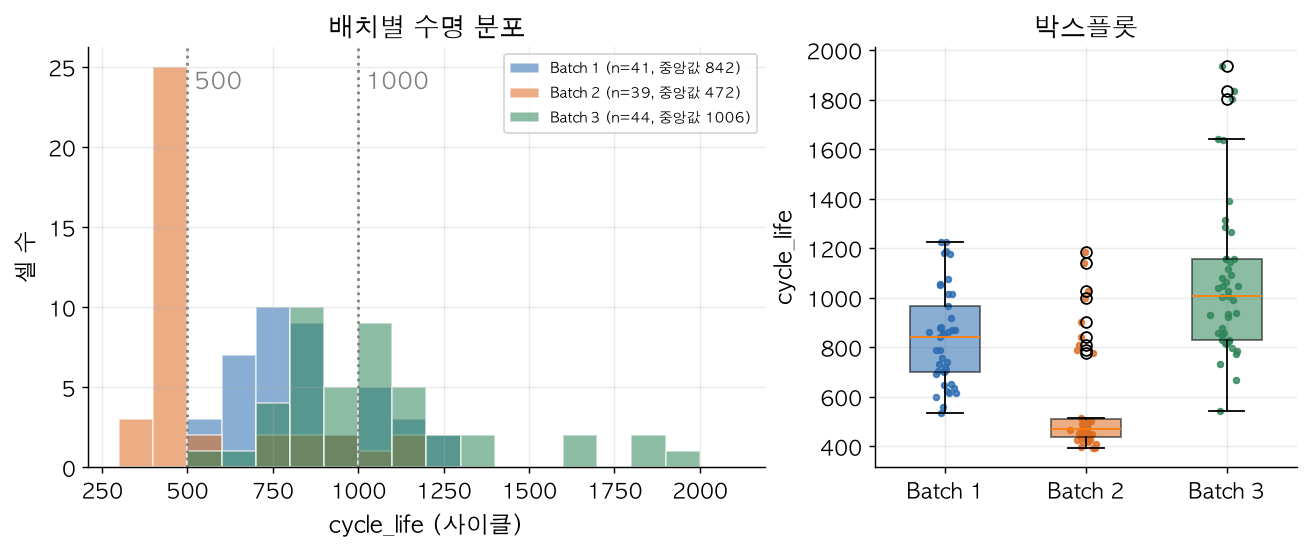

,count,mean,std,median,skew,장수명(>1000)%,단수명(<500)%
batch,,,,,,,
batch1,41,838.59,194.89,842.0,0.53,24,0
batch2,39,565.74,222.20,472.0,1.64,8,72
batch3,44,1059.66,313.87,1005.5,1.26,52,0


In [3]:
run_eda("src.eda.q1")
display(Image(str(FIG_DIR / "q1_cycle_life_dist.png"), width=900))
v = ds[ds.valid]
t = v.groupby("batch").cycle_life.agg(["count", "mean", "std", "median", "skew"]).round(2)
t["장수명(>1000)%"] = v.groupby("batch").cycle_life.apply(lambda s: round((s > 1000).mean() * 100)); t["단수명(<500)%"] = v.groupby("batch").cycle_life.apply(lambda s: round((s < 500).mean() * 100))
display(t)

**확인한 내용**
- 분포가 배치마다 다르다 (중앙값 B1 842 / B2 472 / B3 1,006). B2는 72%가 500 사이클 미만이다.
- B2는 **두 집단**이다: 일반 30셀(392~514)과 `newstructure` 9셀(777~1,186). newstructure는 B3 44셀과 같은 구조라 배치 효과와 셀 구조 효과가 겹친다.
- 이상치는 모두 장수명 newstructure 셀이다. 가장 짧은 셀은 가장 공격적인 충전(5.4C(80%)-5.4C: 534·559).
- B2 일반 30셀이 짧은 이유는 충전 조건만으로 설명되지 않는다(같은 4.8C(80%)-4.8C: B1 753 / B2 484). 초기 용량이 배치마다 다르다(평균 1.082 / 1.095 / 1.066Ah) → 셀 로트·측정 조건 차이 **가설** (현 데이터로 검증 불가).

**시사점** 550 기준 분류는 B1 학습 단수명이 1개뿐이라 성립하지 않는다 → **Regression**, 타깃은 log10, B2는 집단별로 해석.

## Q2. 열화 곡선 — 방전 용량은 어떻게 감소하는가?

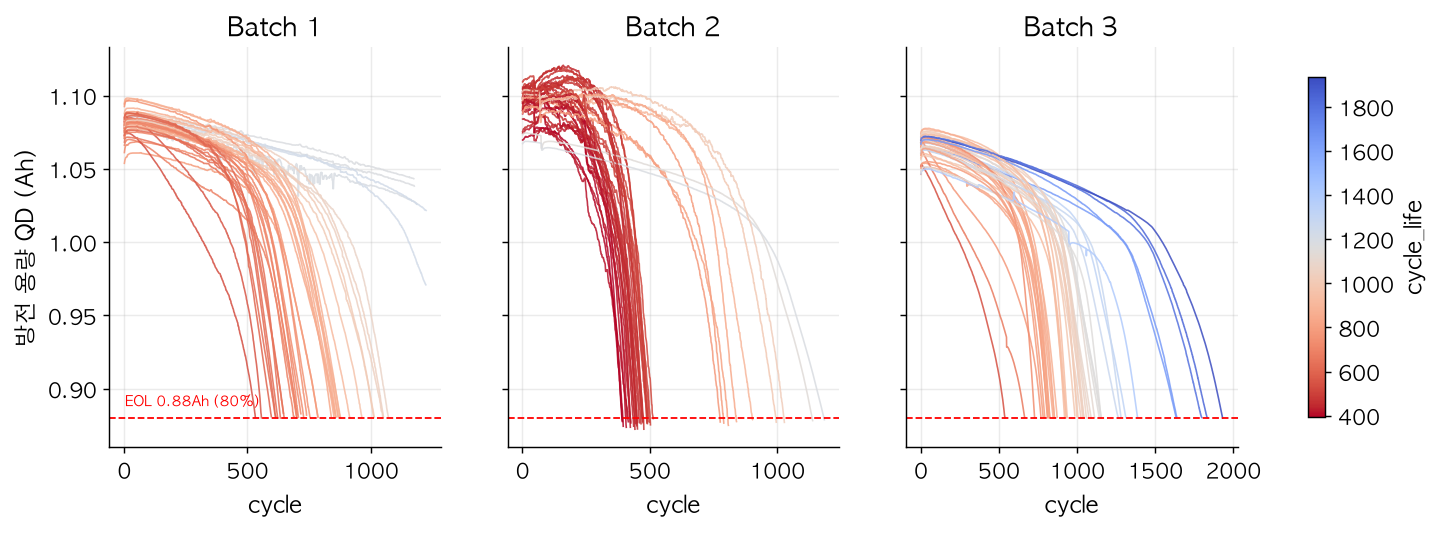

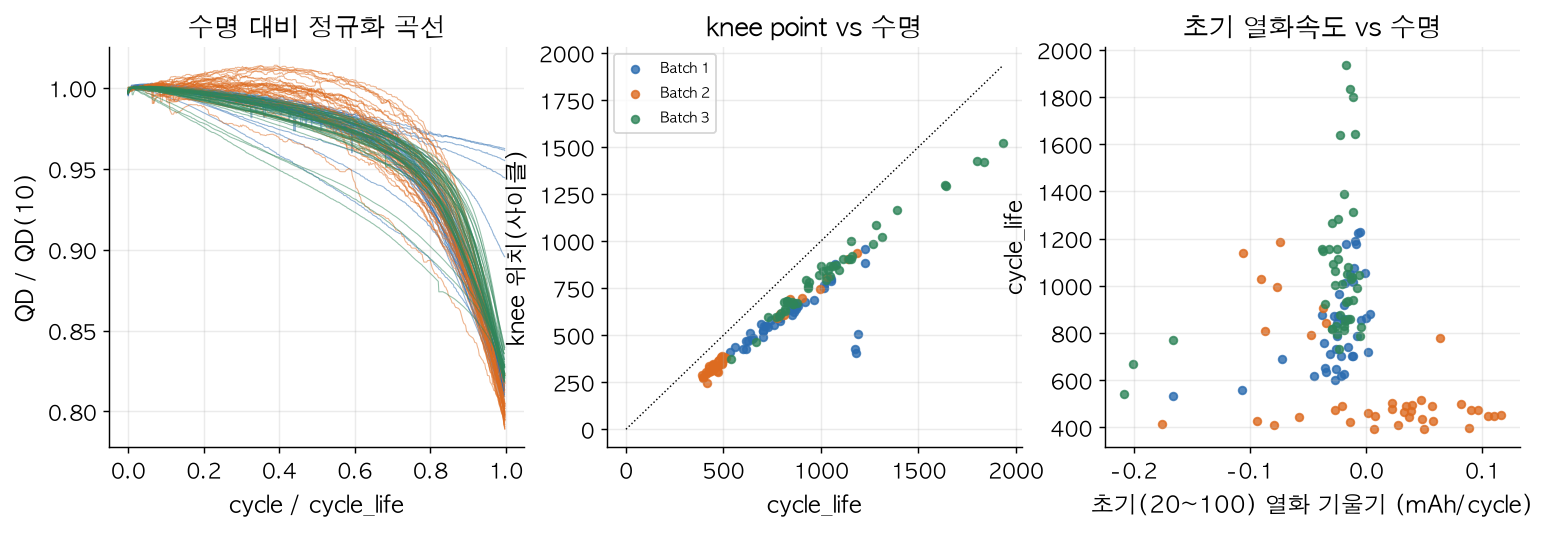

,knee 위치/수명 (중앙값),knee 후/전 기울기 배수 (중앙값)
batch,,
batch1,0.75,10.03
batch2,0.75,11.34
batch3,0.79,9.98


In [4]:
run_eda("src.eda.q2")
display(Image(str(FIG_DIR / "q2_degradation_curves.png"), width=900)); display(Image(str(FIG_DIR / "q2_knee_and_early_slope.png"), width=900))
q2 = pd.read_csv(R("eda/q2_degradation.csv"))
display(q2.groupby("batch")[["knee_frac", "accel"]].median().round(2).rename(columns={"knee_frac": "knee 위치/수명 (중앙값)", "accel": "knee 후/전 기울기 배수 (중앙값)"}))

**확인한 내용** 열화는 일정하지 않고 knee 이후 약 10배 가속된다. knee는 수명의 약 75% 지점이라 초기 예측에는 쓸 수 없다. B2 단수명 셀은 초기에 용량이 오른 뒤(1.10→1.12Ah) 400~500 사이클에서 급락한다. 초기(20~100) QD 기울기와 수명의 상관은 B1 +0.61(p<0.001), B2 −0.25(p=0.12), B3 +0.19(p=0.21) → **B1에서만 유의**.

**시사점** QD 총량·기울기 피처는 배치 간 이식이 어렵다 → 전압 구간별 변화인 ΔQ(V)가 필요하다.

## Q3. ΔQ(V) = Q₁₀₀(V) − Q₁₀(V) — 초기 사이클에서 차이가 보이는가?

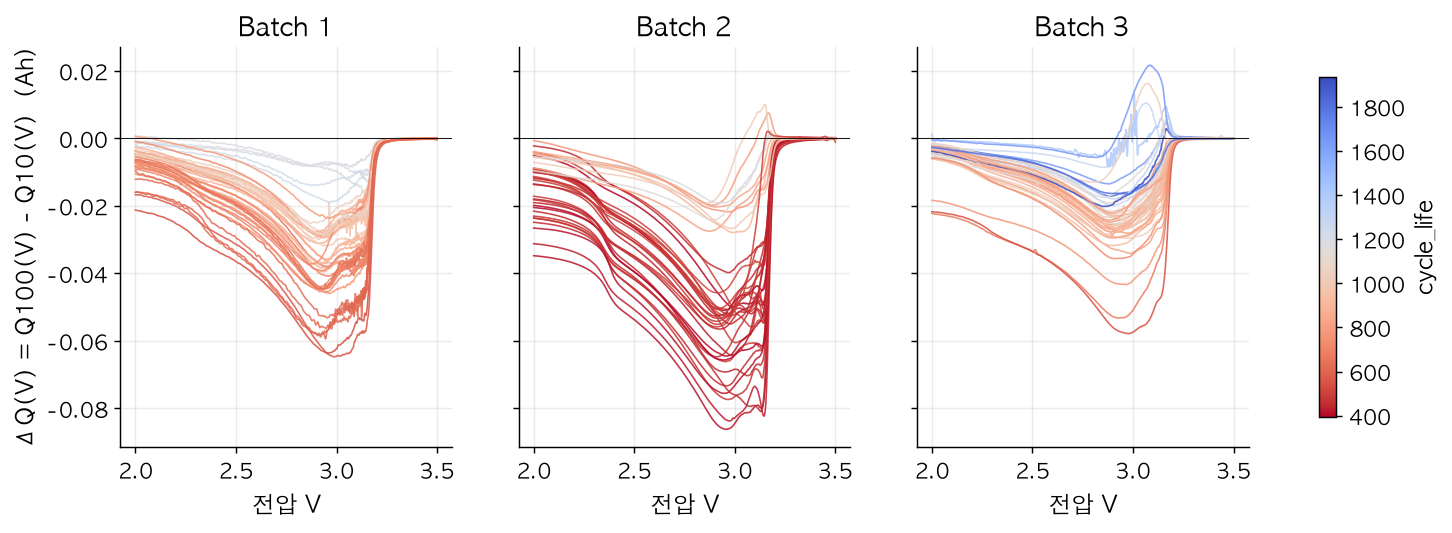

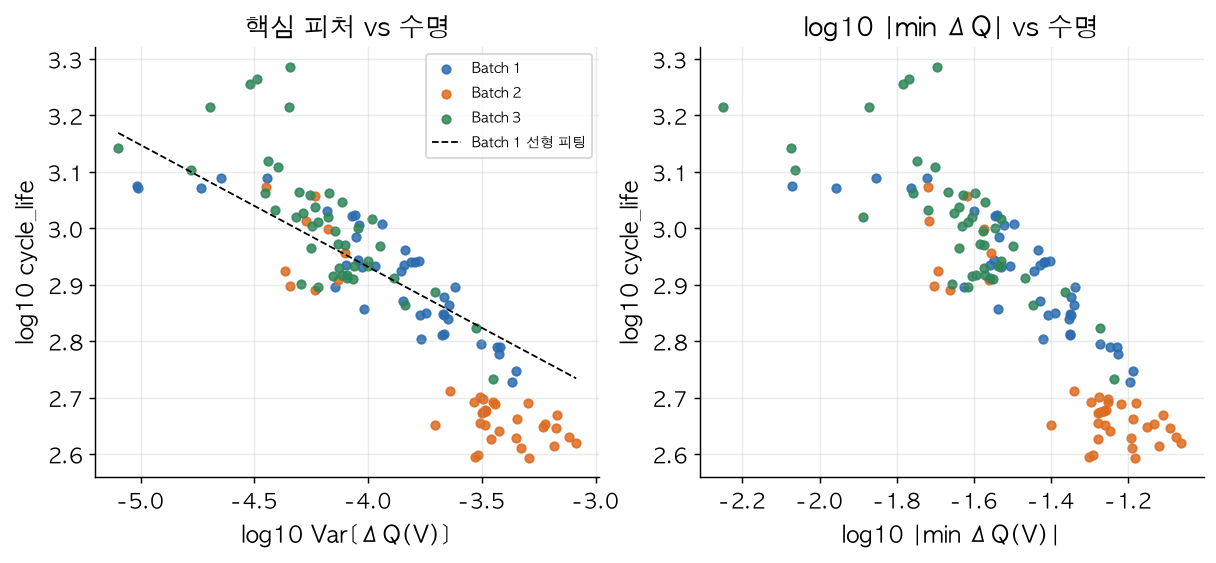

,batch1,batch2,batch3
ΔQ 통계 vs log10 수명 (Spearman),,,
log_dq_var,-0.88,-0.71,-0.80
log_dq_min,-0.85,-0.66,-0.78
log_dq_abs_mean,-0.83,-0.70,-0.76
dq_kurt,0.22,0.50,0.32
dq_skew,-0.57,-0.15,0.06


In [5]:
run_eda("src.eda.q3")
display(Image(str(FIG_DIR / "q3_deltaQ_curves.png"), width=900)); display(Image(str(FIG_DIR / "q3_deltaQ_feature_scatter.png"), width=800))
from scipy.stats import spearmanr
v = ds[ds.valid]
rows = {f: {b: round(spearmanr(g[f], g.y)[0], 2) for b, g in v.groupby("batch")} for f in ["log_dq_var", "log_dq_min", "log_dq_abs_mean", "dq_kurt", "dq_skew"]}
display(pd.DataFrame(rows).T.rename_axis("ΔQ 통계 vs log10 수명 (Spearman)"))

**확인한 내용** 초기 QD는 겹쳐도 ΔQ(V)는 갈린다(단수명은 −0.06~−0.09Ah까지 깊게 파임). `log Var[ΔQ]`와 log 수명의 상관은 B1 −0.88 / B2 −0.71 / B3 −0.80으로 세 배치에서 같은 방향이다(B2는 집단 구분 효과 포함: 일반 −0.38, newstructure −0.17). 왜도는 B1에서만 유의하다.

**시사점** 핵심 피처는 `log Var[ΔQ]` 중심의 ΔQ 통계(log 변환).

## Q4. 충전 조건(C-rate)과 수명의 관계는?

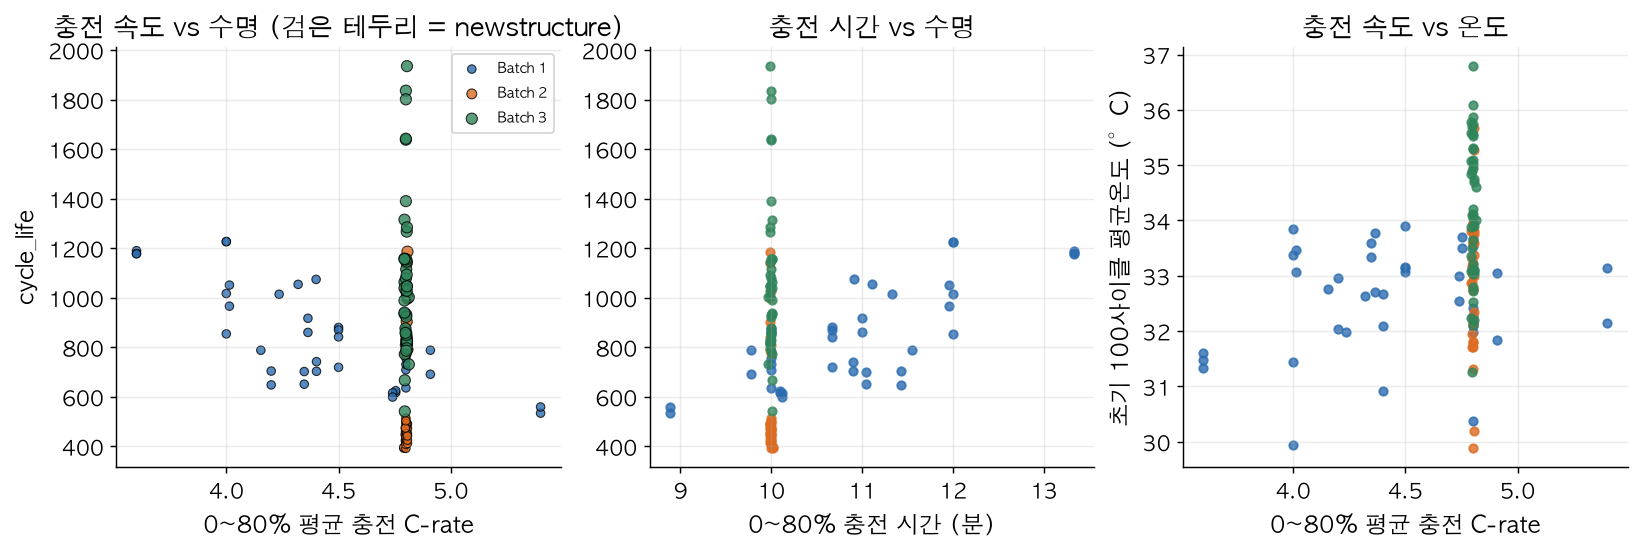

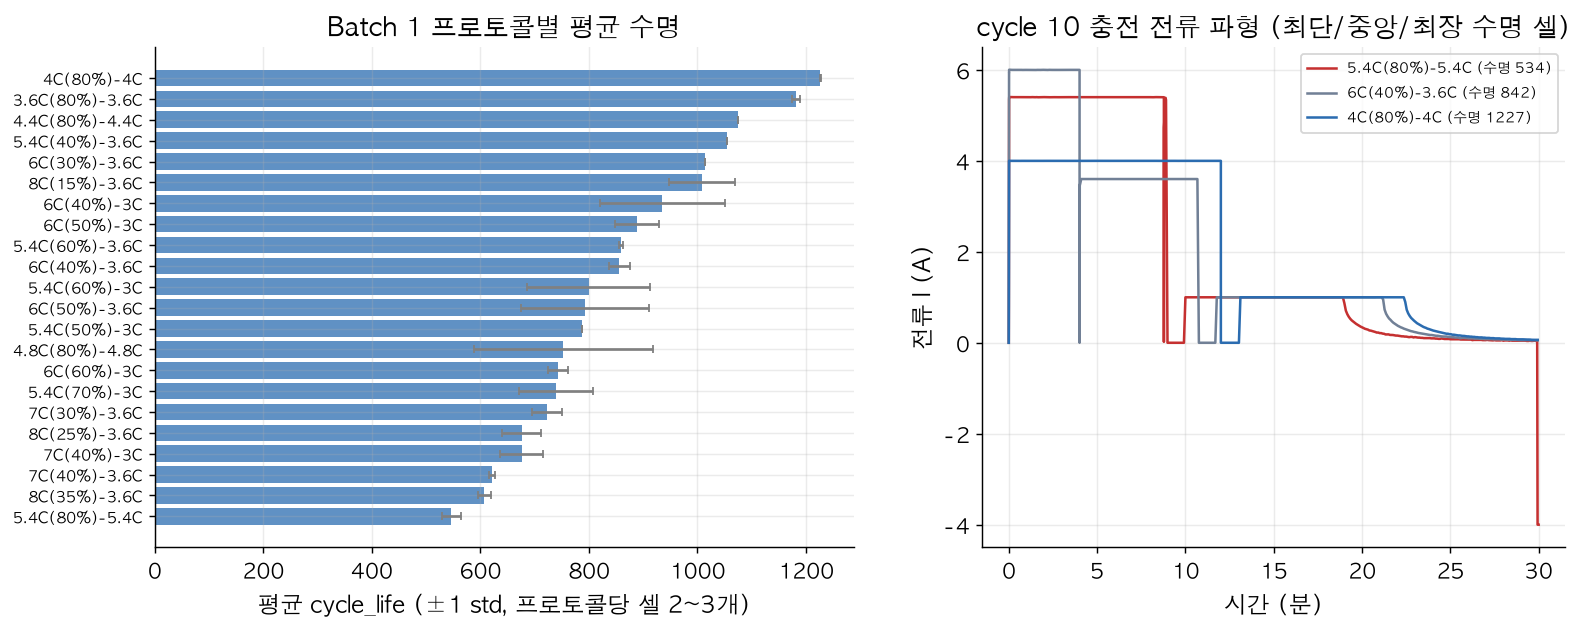

,feature,batch1,batch2,batch3
0,충전시간 평균,+0.60 (p=0.000),-0.80 (p=0.000),+0.21 (p=0.162)
1,평균 C-rate,-0.61 (p=0.000),+0.32 (p=0.046),-0.13 (p=0.393)
2,ΔQ 왜도,-0.57 (p=0.000),-0.15 (p=0.356),+0.06 (p=0.721)
3,QD 기울기(2~100),+0.46 (p=0.003),-0.27 (p=0.095),+0.09 (p=0.569)
4,QD 기울기(20~100),+0.61 (p=0.000),-0.25 (p=0.123),+0.19 (p=0.213)
5,ΔQ 첨도,+0.22 (p=0.164),+0.50 (p=0.001),+0.32 (p=0.034)
6,전환 SOC,+0.23 (p=0.144),+0.29 (p=0.076),+0.44 (p=0.003)


In [6]:
run_eda("src.eda.q4")
display(Image(str(FIG_DIR / "q4_crate_vs_life.png"), width=900)); display(Image(str(FIG_DIR / "q4_protocol_and_current.png"), width=900))
display(pd.read_csv(R("eda/sign_stability.csv")) if (pathlib.Path(R("eda/sign_stability.csv"))).exists() else "run: python -m src.analysis.sign_stability")

**확인한 내용**
- B1에서는 "빠를수록 짧다": 평균 C-rate와 수명 −0.61 (5.4C(80%)-5.4C 546 vs 4C(80%)-4C 1,227). B2 +0.32, B3 −0.13.
- B2·B3는 모든 프로토콜이 0~80% 충전 10분으로 통일되어 평균 C-rate가 거의 상수 → "빠른 충전→발열→열화"는 이 데이터로 판단할 수 없다.
- 같은 4.8C(80%)-4.8C가 B1 753 / B2 일반 484 / B2 newstructure 872 / B3 1,564 → **프로토콜 → 수명 관계가 배치마다 다르다**.
- 같은 프로토콜 셀은 수명이 비슷하다(프로토콜 내 CV 6.1%·7.1% vs 프로토콜 간 22.7%·39.9%) → 분할 단위는 반드시 **프로토콜**.

**시사점** 프로토콜 피처는 보조용이고 셀 상태 신호(ΔQ)가 필요하다. 프로토콜 단위 Hold-out으로 누수를 막는다.

## Q5. 상관관계 — 어떤 신호가 수명과 연관되는가? 다중공선성은?

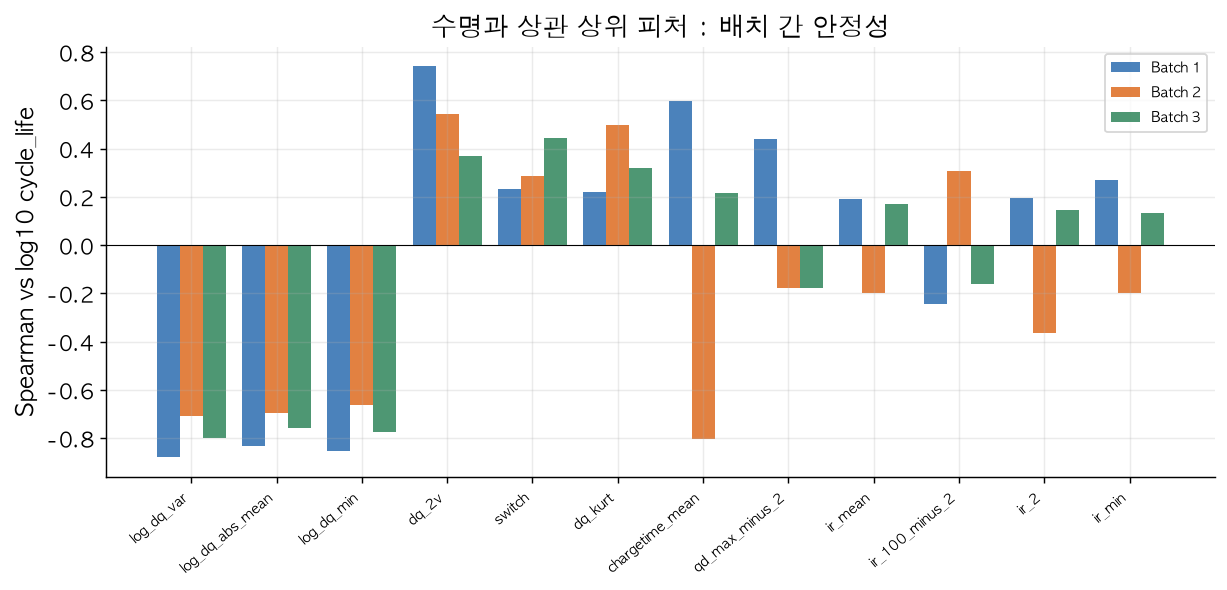

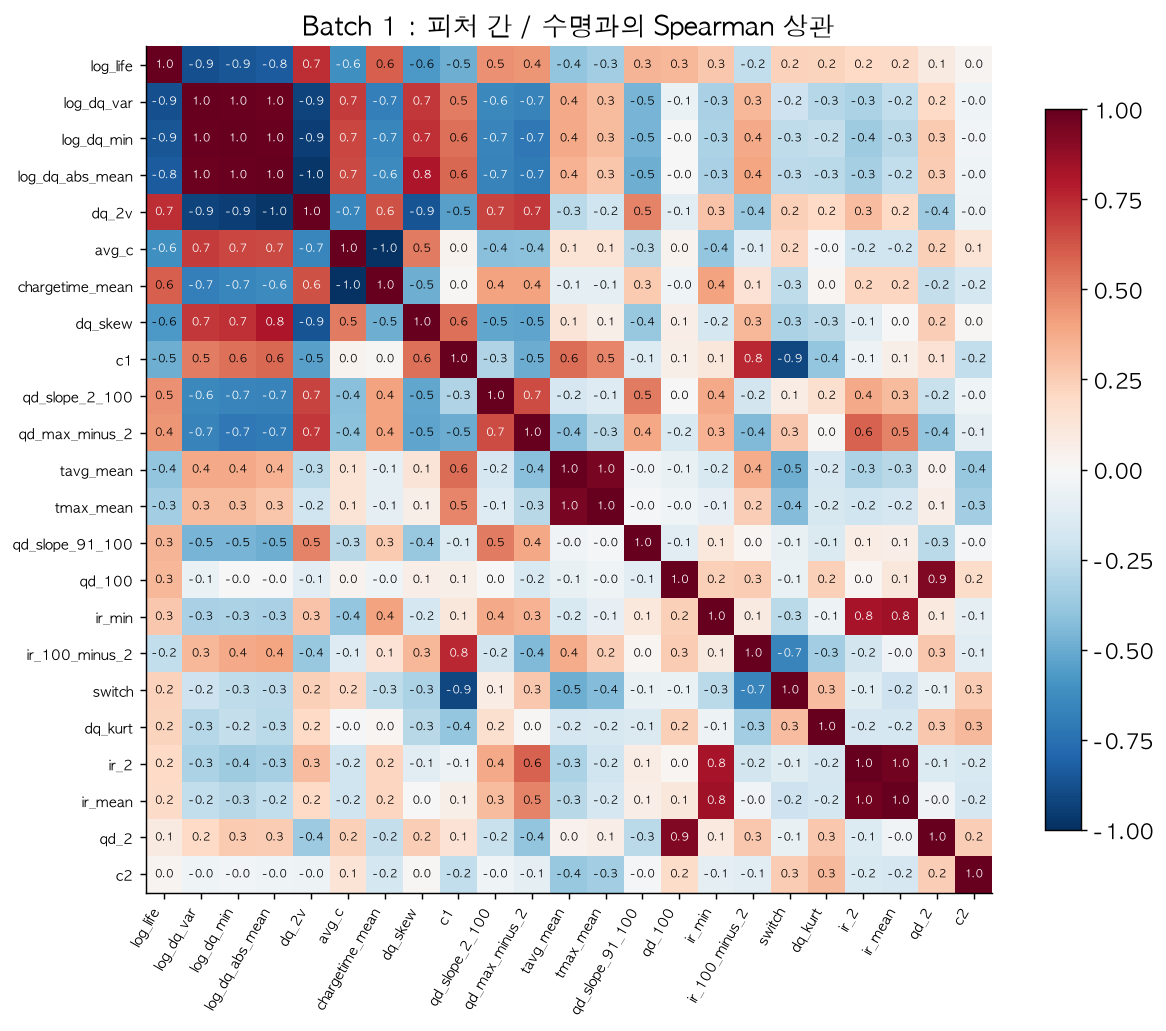

In [7]:
run_eda("src.eda.q5")
display(Image(str(FIG_DIR / "q5_feature_stability.png"), width=900)); display(Image(str(FIG_DIR / "q5_corr_heatmap.png"), width=700))

**확인한 내용** 가장 강한 신호는 `log Var[ΔQ]`(−0.88 / −0.71 / −0.80)이고 `log|min|`, `log|mean|`이 뒤를 잇는다. 세 배치에서 부호가 같은 피처 10개 중 |ρ| ≥ 0.5를 유지하는 것은 ΔQ 계열 3개뿐이다. 충전시간은 B2에서 진짜 반전(+0.60 → −0.80), 그 외 B1 상위 피처는 B1에서만 유의하다. 다중공선성이 심하다(|r| ≥ 0.9 쌍 11개, 22개 전체 VIF 최대 6,488 → 선별 6개 2.2).

**시사점** "B1 상관 상위 = 좋은 피처"가 아니다. 신호는 사실상 `log Var[ΔQ]` 하나에 집중되므로 소수 피처와 규제 선형 모델을 우선한다.